In [2]:
import dataclasses
import glob
import json

import matplotlib as mpl
import matplotlib.pyplot as plt

from lib.plots import set_axis, plot_arc, plot_rect

In [3]:
task_id = "1-control_no_crossing"

config_files = glob.glob(f"{task_id}/_configs/config-*.json")
configs = []

for filename in config_files:
    with open(filename) as file:
        configs.append(json.load(file))

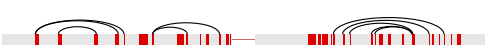

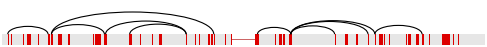

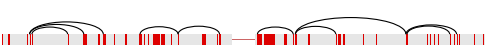

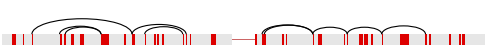

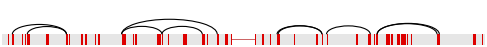

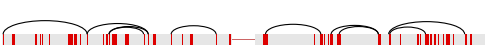

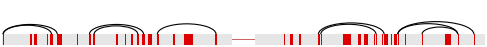

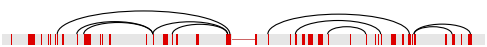

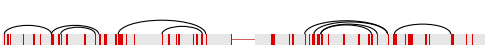

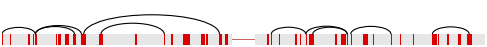

In [5]:
@dataclasses.dataclass
class DomainArchitecture:
    size: int
    loops: list[tuple[int, int]]
    islands: list[tuple[int, int]]


for config in configs:
    sweep_data = config["@meta"]["sweep_data"]
    config_id = sweep_data["config_id"]

    domains = []

    for interval, loops, islands in zip(
        sweep_data["domain_intervals"],
        sweep_data["domain_loops"],
        sweep_data["domain_acetylation_islands"],
    ):
        domains.append(
            DomainArchitecture(
                size=(interval[1] - interval[0]),
                loops=[(i, j) for i, j in loops],
                islands=[(start, end) for start, end in islands],
            )
        )

    linker_width = 20
    linker_height = 0.1
    loop_height_scale = 0.1
    loop_height_exponent = 0.75

    domain_style = dict(facecolor="0.9")
    island_style = dict(facecolor="#d00")
    linker_style = dict(facecolor="#c66")
    loop_style = dict(linewidth=0.4, color="black")

    fig, ax = plt.subplots(figsize=(2.5, 0.3))

    offset = 0
    max_y = 0

    for domain_index, domain in enumerate(domains):
        if domain_index > 0:
            x1 = offset
            x2 = offset + linker_width
            y1 = 0.5 - linker_height / 2
            y2 = 0.5 + linker_height / 2
            plot_rect(ax, x1, y1, x2, y2, **linker_style)
            offset += linker_width

        x1 = offset
        x2 = offset + domain.size
        y1 = 0
        y2 = 1
        plot_rect(ax, x1, y1, x2, y2, **domain_style)

        for start, end in domain.islands:
            x1 = offset + start
            x2 = offset + end
            plot_rect(ax, x1, y1, x2, y2, **island_style)

        for i, j in domain.loops:
            x = offset + (i + j) / 2
            y = 1
            w = j - i
            h = loop_height_scale * w**loop_height_exponent
            plot_arc(ax, x, y, w, h, theta1=0, theta2=180, **loop_style)
            max_y = max(max_y, h)

        offset += domain.size

    ax.set_xlim(0, offset)
    ax.set_ylim(0, 4)

    set_axis(ax, "none")

    fig.savefig(f"_figs/Domain-{task_id}-{config_id}.svg")